In [ ]:
#melakukan load audio dan menampilkan beberapa komponen
import librosa

audio, fs = librosa.load("stm.wav", sr=None)
duration = len(audio) / fs
num_samples = len(audio)
amp_min = audio.min()
amp_max = audio.max()

print(f"Durasi : {duration:.4f}, Sample_rate : {fs}, Jumlah_sample : {num_samples}, amp_min : {amp_min:.4f}, amp_max : {amp_max:.4f}")

c:\Users\afnan\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Durasi : 16.7190, Sample_rate : 44100, Jumlah_sample : 737307, amp_min : -0.6700, amp_max : 0.7012


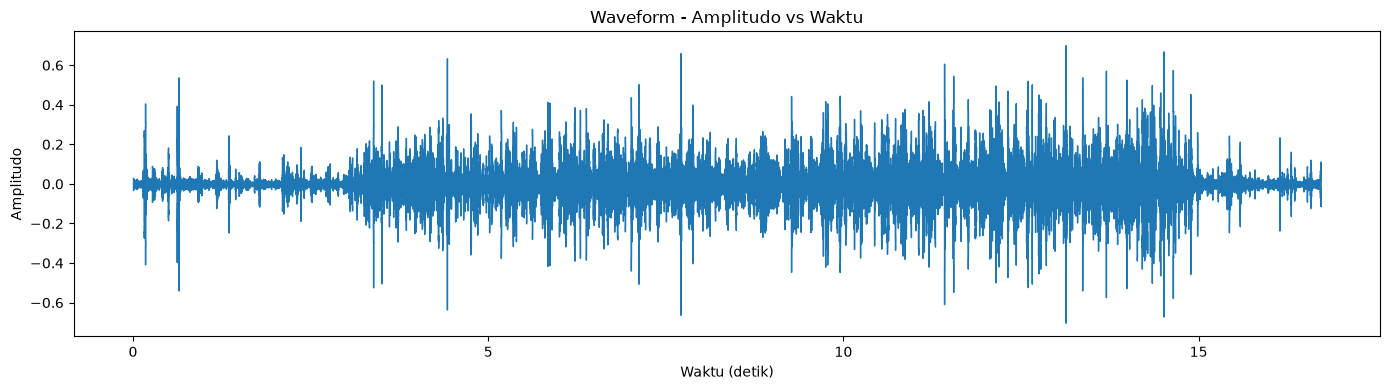

In [4]:
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
librosa.display.waveshow(audio, sr=fs)
plt.title("Waveform - Amplitudo vs Waktu")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

Dari waveform diatas terlihat bagian yang tidak terlalu aktif adalah noise sementara bagian yang lebih aktif adalah noise dan suara

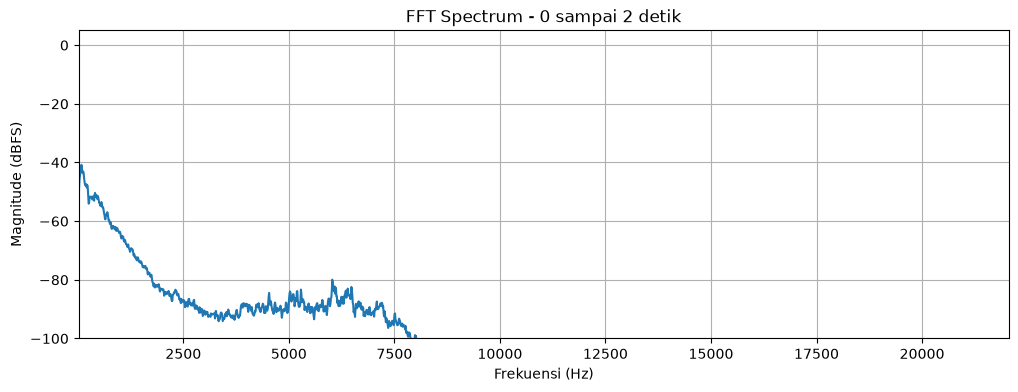

In [ ]:
from scipy.signal import get_window
#mengatur bagian yang diambil
mulai = 0
selesai = 2
#menggunakan jendela sebesar 4096 dengan hop setengahnya jendela
n_fft = 4096
hop = n_fft // 2
w = get_window("hann", n_fft)
seg_audio = audio[mulai * fs: fs * selesai]
#menyimpan hasil fft dari tiap segmen
spectra = []

for start in range(0, len(seg_audio) - n_fft + 1, hop):

    x = seg_audio[start:start + n_fft]
    x = x * w
    X = np.abs(np.fft.rfft(x))
    X = X / np.sum(w)
    X[1:-1] *= 2

    spectra.append(X)

spectra = np.array(spectra)

X_mean = np.mean(spectra, axis=0)
#mengubah magnitude menjadi db
dbfs = 20 * np.log10(np.maximum(X_mean, 1e-12))

freqs = np.fft.rfftfreq(n_fft, 1/fs)

plt.figure(figsize=(12, 4))

plt.plot(freqs, dbfs)

plt.title("FFT Spectrum - 0 sampai 2 detik")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitude (dBFS)")

plt.xlim(20, fs / 2)
plt.ylim(-100, 5)

plt.grid()
plt.show()

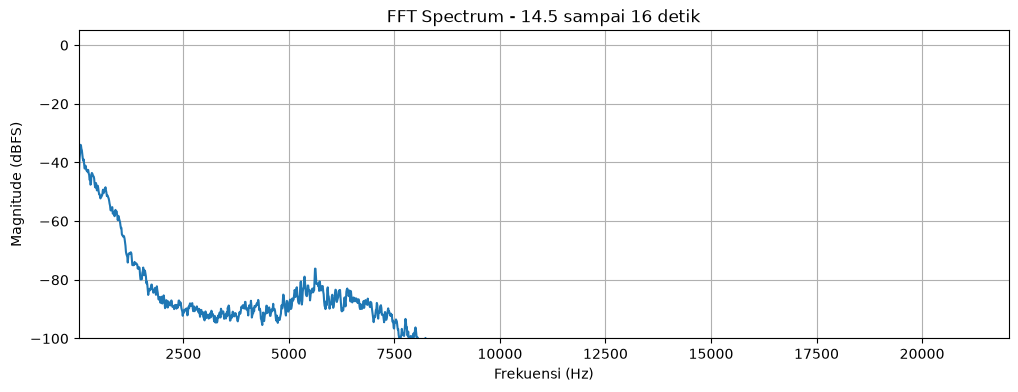

In [6]:
from scipy.signal import get_window

mulai = 14.5
selesai = 16

n_fft = 4096
hop = n_fft // 2
w = get_window("hann", n_fft)
seg_audio = audio[int(mulai * fs): int(fs * selesai)]

spectra = []

for start in range(0, len(seg_audio) - n_fft + 1, hop):

    x = seg_audio[start:start + n_fft]
    x = x * w
    X = np.abs(np.fft.rfft(x))
    X = X / np.sum(w)
    X[1:-1] *= 2

    spectra.append(X)

spectra = np.array(spectra)

X_mean = np.mean(spectra, axis=0)

dbfs = 20 * np.log10(np.maximum(X_mean, 1e-12))

freqs = np.fft.rfftfreq(n_fft, 1/fs)

plt.figure(figsize=(12, 4))

plt.plot(freqs, dbfs)

plt.title("FFT Spectrum - 14.5 sampai 16 detik")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitude (dBFS)")

plt.xlim(20, fs / 2)
plt.ylim(-100, 5)

plt.grid()
plt.show()

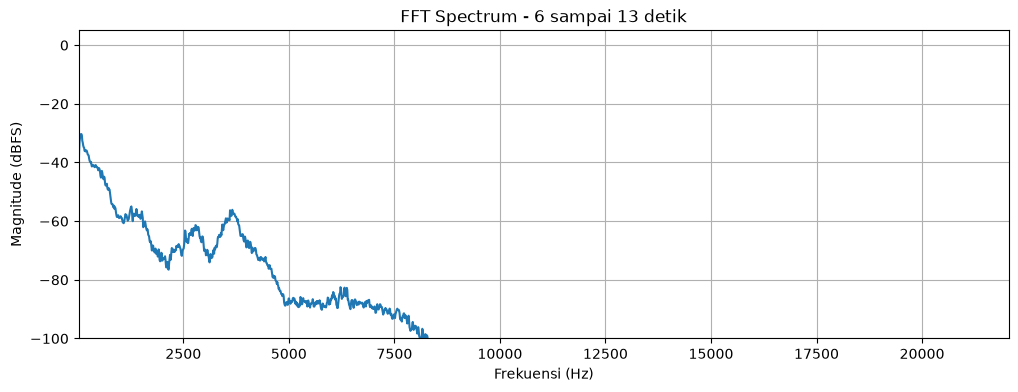

In [7]:
from scipy.signal import get_window

mulai = 6
selesai = 13

n_fft = 4096
hop = n_fft // 2
w = get_window("hann", n_fft)
seg_audio = audio[int(mulai * fs): int(fs * selesai)]

spectra = []

for start in range(0, len(seg_audio) - n_fft + 1, hop):

    x = seg_audio[start:start + n_fft]
    x = x * w
    X = np.abs(np.fft.rfft(x))
    X = X / np.sum(w)
    X[1:-1] *= 2

    spectra.append(X)

spectra = np.array(spectra)

X_mean = np.mean(spectra, axis=0)

dbfs = 20 * np.log10(np.maximum(X_mean, 1e-12))

freqs = np.fft.rfftfreq(n_fft, 1/fs)

plt.figure(figsize=(12, 4))

plt.plot(freqs, dbfs)

plt.title("FFT Spectrum - 6 sampai 13 detik")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitude (dBFS)")

plt.xlim(20, fs / 2)
plt.ylim(-100, 5)

plt.grid()
plt.show()

Dari percobaan pada segmen hanya noise dan noise+suara didapat kesimpulan sebagai berikut

segmen noise (0-2 detik) dan (14.5 - 16 detik) terlihat bahwa frekuensi dominan ada di rentang 0 kemudian menurun saat ke 2500Hz dan sedikit menaik lagi dikisaran 5000Hz sampai 7500Hz, kemudian saat dicoba pada bagian berisi suara (6 - 13 detik) terdapat puncak baru di sekitar 1500Hz sampai 5000Hz kemudian menurun lagi saat menuju 7500Hz, yang berarti noise statis terkonsentrasi di frekuensi 0-1500Hz dan 5000-10000Hz dan suara berada di frekuensi 1500-5000Hz.

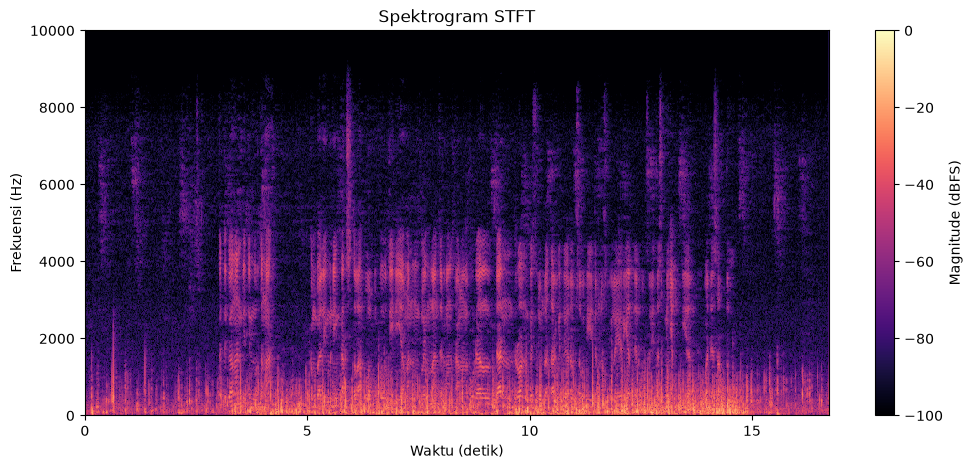

In [8]:
import librosa
import librosa.display

n_fft = 2048              
hop_length = n_fft // 4   

D = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length, window="hann")

w = get_window("hann", n_fft)
mag = np.abs(D) / np.sum(w)
mag[1:-1, :] *= 2
S_dbfs = 20 * np.log10(np.maximum(mag, 1e-12))

plt.figure(figsize=(12, 5))
librosa.display.specshow(S_dbfs, sr=fs, hop_length=hop_length,
                         x_axis="time", y_axis="hz",
                         vmin=-100, vmax=0)   
plt.colorbar(label="Magnitude (dBFS)")
plt.title("Spektrogram STFT")
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi (Hz)")
plt.ylim(0, 10000)   
plt.show()

Dari gambar spektogram STFT dapat terlihat bahwa di keseluruhan audio rentang frekuensi 0 - 2000 selalu menyala dari awal hingga akhir yang mengindikasikan noise, selain itu di frekuensi 5000 - 8000Hz juga beberapa kali magnitudo terlihat terang walau tidak konsisten. Saat di bagian ada suara, muncul area terang baru yaitu di frekuensi 2000 - 5000Hz.

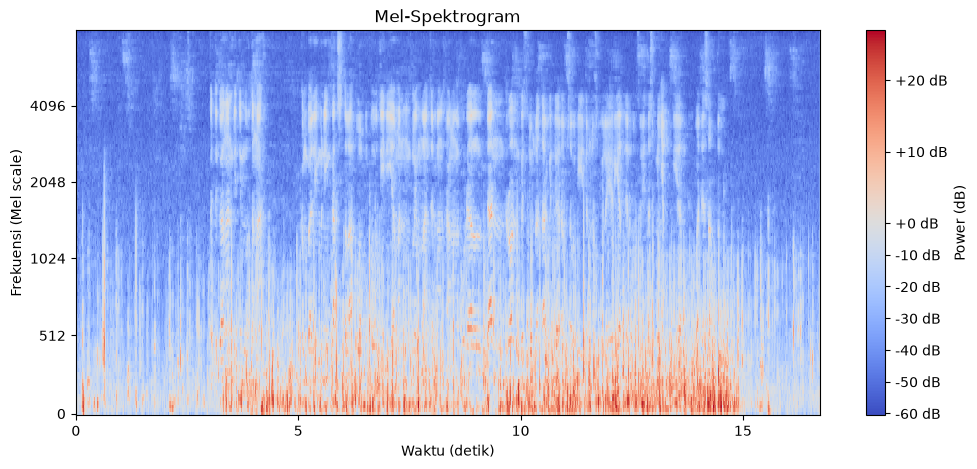

In [9]:
n_fft = 2048
hop_length = n_fft // 4
n_mels = 128   

S_mel = librosa.feature.melspectrogram(y=audio, sr=fs, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, fmax=8000, power=2.0)
S_mel_db = librosa.power_to_db(S_mel, ref=1.0, top_db=None)

plt.figure(figsize=(12, 5))
librosa.display.specshow(S_mel_db, sr=fs, hop_length=hop_length, x_axis="time", y_axis="mel", fmax=8000)
plt.colorbar(format="%+2.0f dB", label="Power (dB)")
plt.title("Mel-Spektrogram")
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi (Mel scale)")
plt.show()

Saat diubah ke mel-spektrogram suara manusia terlihat padat dan jelas karena skala mel dirancang untuk mendekati cara telinga manusia mempersepsikan frekuensi yang dimana frekuensi lebih rendah lebih terasa jika terjadi perubahan sementara frekuensi tinggi berlaku sebaliknya

In [11]:
target_fs = 8000
M = fs // target_fs

audio_naive = audio[::M]

print("Audio asli      :", len(audio), "samples")
print("Audio naive     :", len(audio_naive), "samples")
print("Sampling rate   :", target_fs, "Hz")

Audio asli      : 737307 samples
Audio naive     : 147462 samples
Sampling rate   : 8000 Hz


In [13]:
from scipy.signal import resample_poly
audio_resampled = resample_poly(
    audio,
    up=target_fs,
    down=fs
)

print("Audio asli          :", len(audio), "samples")
print("Audio resampled     :", len(audio_resampled), "samples")
print("Sampling rate       :", target_fs, "Hz")

Audio asli          : 737307 samples
Audio resampled     : 133752 samples
Sampling rate       : 8000 Hz


In [15]:
n_fft = 2048
hop_length = 512

# Spektrogram naive
D_naive = librosa.stft(
    audio_naive,
    n_fft=n_fft,
    hop_length=hop_length
)

S_naive = librosa.amplitude_to_db(
    np.abs(D_naive),
    ref=np.max
)

# Spektrogram resampling standar
D_resampled = librosa.stft(
    audio_resampled,
    n_fft=n_fft,
    hop_length=hop_length
)

S_resampled = librosa.amplitude_to_db(
    np.abs(D_resampled),
    ref=np.max
)

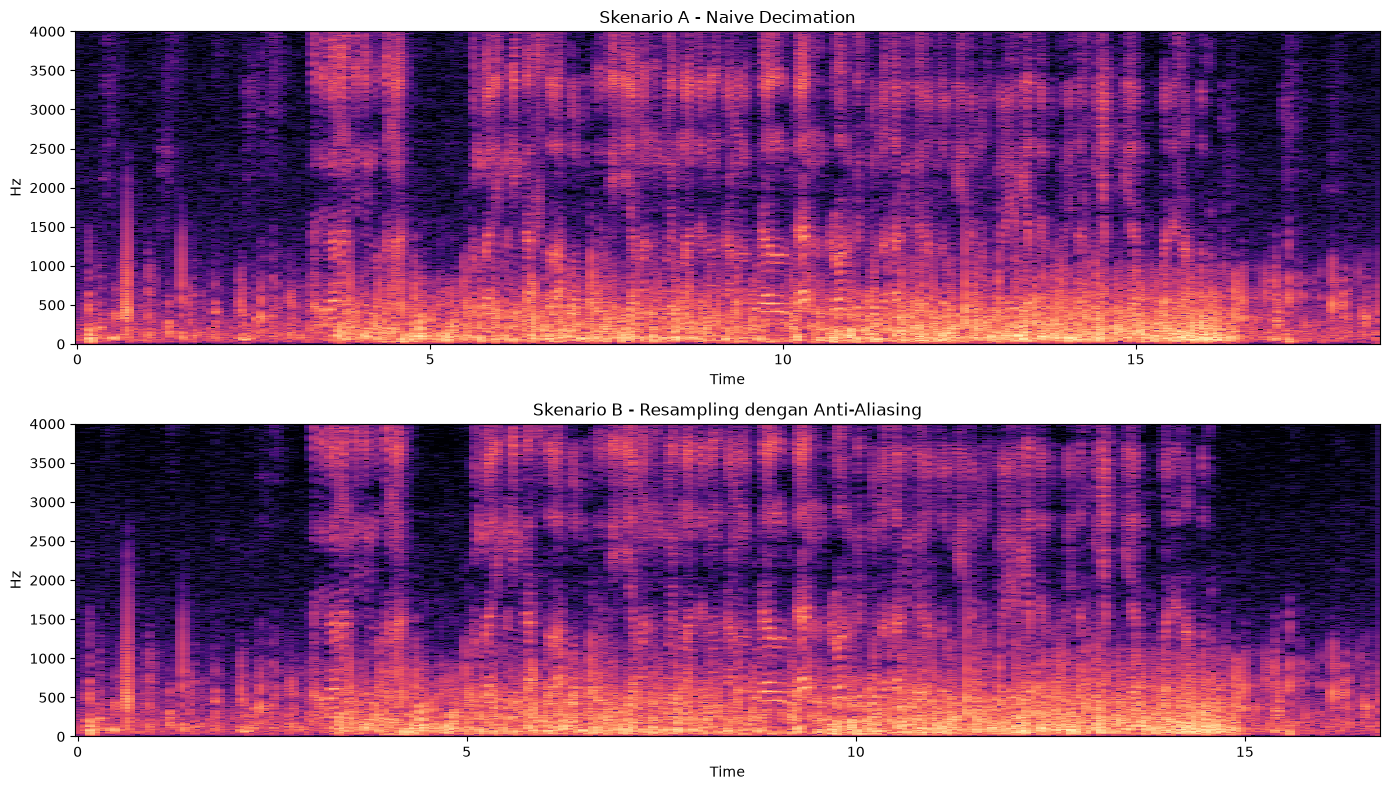

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

librosa.display.specshow(
    S_naive,
    sr=target_fs,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
    ax=ax[0]
)

ax[0].set_title("Skenario A - Naive Decimation")
ax[0].set_ylim(0, target_fs / 2)

librosa.display.specshow(
    S_resampled,
    sr=target_fs,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
    ax=ax[1]
)

ax[1].set_title("Skenario B - Resampling dengan Anti-Aliasing")
ax[1].set_ylim(0, target_fs / 2)

plt.tight_layout()
plt.show()

dari kedua gambar spektrogram terlihat di bagian area kiri atas dan kanan atas berbeda, pada kasus A nampak beberapa magnitude yang kemungkinan berasal dari pantulan frekuensi tinggi karena tidak difilter terlebih dahulu lalu di kasus B area tersebut nampak lebih bersih karena frekuensi tinggi sudah dibersihkan